# CSI4142 Assignment 3

1. Andrew Pham - 300226985

2. Kevin Yao - 300295024

Work split:
- Kevin: Part 1 - Regression Study
- Andrew: Part 2 - Classification Study

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer

# Part 1 Regression Study

## 1.1 Dataset

- Name: Housing Prices Regression
- Author: Published on Kaggle by Den_Kuznetz
- Purpose: This dataset is used to predict house prices from property features such as size, rooms, location, and amenities.
- Shape: 500 rows, 12 columns

In [5]:
file_path = "real_estate_dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "denkuznetz/housing-prices-regression",
    path=file_path,
)

print(df.shape)
df.head()

100%|██████████| 46.5k/46.5k [00:00<00:00, 741kB/s]

(500, 12)


,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## 1.2 Data Cleaning

In [6]:
housing_df = df.copy()

numeric_columns = [
    "ID",
    "Square_Feet",
    "Num_Bedrooms",
    "Num_Bathrooms",
    "Num_Floors",
    "Year_Built",
    "Has_Garden",
    "Has_Pool",
    "Garage_Size",
    "Location_Score",
    "Distance_to_Center",
    "Price",
]

for column in numeric_columns:
    housing_df[column] = pd.to_numeric(housing_df[column], errors="coerce")

print("shape:", housing_df.shape)
print("dtypes:")
print(housing_df.dtypes)
print("duplicates:", housing_df.duplicated().sum())
print("missing values before cleaning:")
print(housing_df.isna().sum())

housing_df = housing_df.drop_duplicates().copy()

for column in numeric_columns:
    housing_df[column] = housing_df[column].fillna(housing_df[column].median())

housing_model_df = housing_df.drop(columns=["ID"]).copy()

print("missing values after cleaning:")
print(housing_model_df.isna().sum())
housing_model_df.head()

shape: (500, 12)
dtypes:
ID                      int64
Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Year_Built              int64
Has_Garden              int64
Has_Pool                int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object
duplicates: 0
missing values before cleaning:
ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64
missing values after cleaning:
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distanc

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## 1.3 Categorical Feature Encoding

In [7]:
df_encoded = housing_model_df.copy()

df_encoded["Has_Garden"] = df_encoded["Has_Garden"].map({1: "Yes", 0: "No"})
df_encoded["Has_Pool"] = df_encoded["Has_Pool"].map({1: "Yes", 0: "No"})

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Has_Garden", "Has_Pool"],
    drop_first=True,
    dtype=int,
)

print(df_encoded.columns.tolist())
df_encoded.head()

['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price', 'Has_Garden_Yes', 'Has_Pool_Yes']


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Garage_Size,Location_Score,Distance_to_Center,Price,Has_Garden_Yes,Has_Pool_Yes
0,143.635030,1,3,3,1967,48,8.297631,5.935734,602134.816747,1,1
1,287.678577,1,2,1,1949,37,6.061466,10.827392,591425.135386,0,1
2,232.998485,1,3,2,1923,14,2.911442,6.904599,464478.696880,1,0
3,199.664621,5,2,2,1918,17,2.070949,8.284019,583105.655996,0,0
4,89.004660,4,3,3,1999,34,1.523278,14.648277,619879.142523,1,0


## 1.4 EDA and Outlier Detection

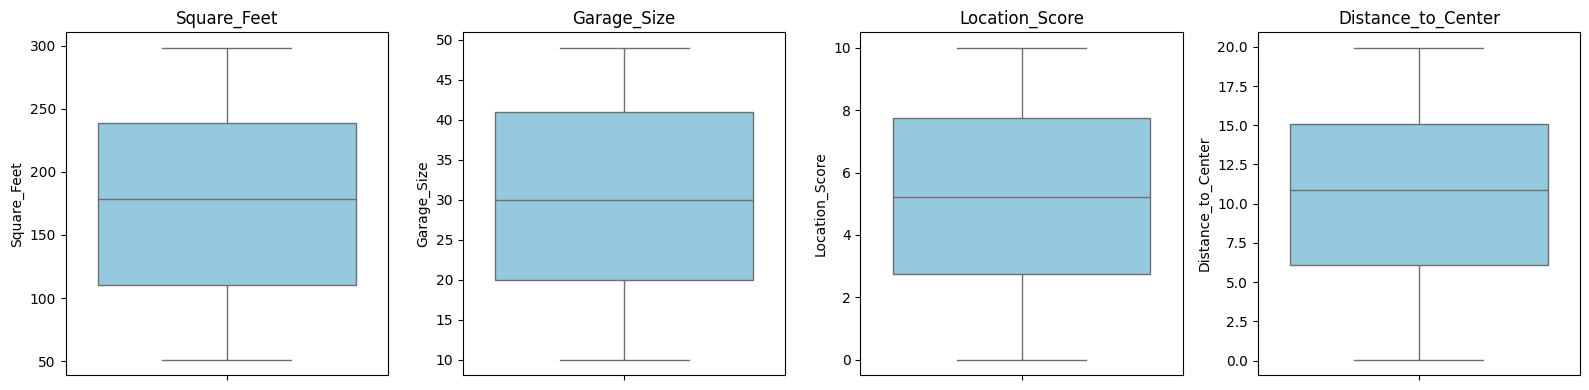

In [8]:
plot_features = [
    "Square_Feet",
    "Garage_Size",
    "Location_Score",
    "Distance_to_Center",
]

fig, axes = plt.subplots(1, len(plot_features), figsize=(16, 4))
for ax, feature in zip(axes, plot_features):
    sns.boxplot(y=df_encoded[feature], ax=ax, color="skyblue")
    ax.set_title(feature)
plt.tight_layout()
plt.show()

In [9]:
iqr_rows = []
for feature in plot_features:
    q1 = df_encoded[feature].quantile(0.25)
    q3 = df_encoded[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_encoded[feature] < lower_bound) | (df_encoded[feature] > upper_bound)).sum()
    iqr_rows.append(
        {
            "feature": feature,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "iqr_outliers": int(outlier_count),
        }
    )

iqr_summary = pd.DataFrame(iqr_rows).sort_values("iqr_outliers", ascending=False)

selected_feature = iqr_summary.iloc[0]["feature"]
df_no_outlier_detection = df_encoded.copy()
injected_outlier_indices = pd.Index([])

if iqr_summary.iloc[0]["iqr_outliers"] == 0:
    selected_feature = "Square_Feet"
    injected_outlier_indices = df_no_outlier_detection.nlargest(3, selected_feature).index
    df_no_outlier_detection.loc[injected_outlier_indices, selected_feature] = (
        df_no_outlier_detection.loc[injected_outlier_indices, selected_feature] * 2
    )
    print(f"no clear outliers were found, so 3 outliers were added to {selected_feature} for LOF.")
else:
    print(f"{selected_feature} had the most visible outliers, so LOF was applied to that feature.")

iqr_summary

no clear outliers were found, so 3 outliers were added to Square_Feet for LOF.


,feature,q1,q3,iqr,iqr_outliers
0,Square_Feet,110.319923,239.031220,128.711298,0
1,Garage_Size,20.000000,41.000000,21.000000,0
2,Location_Score,2.760650,7.732933,4.972284,0
3,Distance_to_Center,6.066754,15.072590,9.005836,0


In [10]:
lof = LocalOutlierFactor(n_neighbors=20)
lof_labels = lof.fit_predict(df_no_outlier_detection[[selected_feature]])

lof_df = df_no_outlier_detection.copy()
lof_df["lof_label"] = np.where(lof_labels == -1, "Outlier", "Inlier")

lof_results = lof_df.loc[
    lof_df["lof_label"] == "Outlier",
    [selected_feature, "Price"],
].copy()

print(f"LOF flagged {len(lof_results)} rows as outliers in {selected_feature}.")
if len(injected_outlier_indices) > 0:
    found_injected = lof_df.loc[injected_outlier_indices, "lof_label"].eq("Outlier").sum()
    print(f"LOF found {found_injected} of the 3 injected outliers.")

df_outliers_handled = lof_df.drop(columns=["lof_label"]).copy()
outlier_indices = lof_df.index[lof_df["lof_label"] == "Outlier"]
df_outliers_handled.loc[outlier_indices, selected_feature] = np.nan
df_outliers_handled[selected_feature] = df_outliers_handled[selected_feature].fillna(
    df_outliers_handled[selected_feature].median()
)

lof_results.head()

LOF flagged 3 rows as outliers in Square_Feet.
LOF found 3 of the 3 injected outliers.


,Square_Feet,Price
261,595.026925,792066.347019
390,595.252571,701186.060496
475,596.482398,666405.154193


## 1.5 Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 1.6 Feature Engineering

In [12]:
df_engineered = df_outliers_handled.copy()
df_engineered["Total_Rooms"] = df_engineered["Num_Bedrooms"] + df_engineered["Num_Bathrooms"]
df_engineered["Square_Feet_per_Floor"] = df_engineered["Square_Feet"] / df_engineered["Num_Floors"]

df_no_outlier_detection_engineered = df_no_outlier_detection.copy()
df_no_outlier_detection_engineered["Total_Rooms"] = (
    df_no_outlier_detection_engineered["Num_Bedrooms"]
    + df_no_outlier_detection_engineered["Num_Bathrooms"]
)
df_no_outlier_detection_engineered["Square_Feet_per_Floor"] = (
    df_no_outlier_detection_engineered["Square_Feet"]
    / df_no_outlier_detection_engineered["Num_Floors"]
)

df_engineered.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Garage_Size,Location_Score,Distance_to_Center,Price,Has_Garden_Yes,Has_Pool_Yes,Total_Rooms,Square_Feet_per_Floor
0,143.635030,1,3,3,1967,48,8.297631,5.935734,602134.816747,1,1,4,47.878343
1,287.678577,1,2,1,1949,37,6.061466,10.827392,591425.135386,0,1,3,287.678577
2,232.998485,1,3,2,1923,14,2.911442,6.904599,464478.696880,1,0,4,116.499243
3,199.664621,5,2,2,1918,17,2.070949,8.284019,583105.655996,0,0,7,99.832311
4,89.004660,4,3,3,1999,34,1.523278,14.648277,619879.142523,1,0,7,29.668220


## 1.7 Empirical Study

We will use MSE, RMSE, and R^2. Lower MSE and RMSE are better, while higher R^2 is better.

In [13]:
from sklearn.model_selection import KFold, cross_validate, train_test_split

split_index = df_no_outlier_detection.index

train_idx, temp_idx = train_test_split(split_index, test_size=0.40, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.375, random_state=42)

print("split sizes:")
print(len(train_idx), len(val_idx), len(test_idx))
print("split ratios:")
print(round(len(train_idx) / len(split_index), 3), round(len(val_idx) / len(split_index), 3), round(len(test_idx) / len(split_index), 3))

dataset_variants = {
    "baseline": {
        "data": df_no_outlier_detection,
        "description": "no outlier handling and no added features",
    },
    "config_2_outliers_handled": {
        "data": df_outliers_handled,
        "description": "LOF outlier handling only",
    },
    "config_3_features_added": {
        "data": df_no_outlier_detection_engineered,
        "description": "feature engineering only",
    },
    "config_4_outliers_and_features": {
        "data": df_engineered,
        "description": "LOF outlier handling and feature engineering",
    },
}

def get_split_data(input_df):
    X = input_df.drop(columns=["Price"])
    y = input_df["Price"]
    return (
        X.loc[train_idx],
        X.loc[val_idx],
        X.loc[test_idx],
        y.loc[train_idx],
        y.loc[val_idx],
        y.loc[test_idx],
    )

split sizes:
300 125 75
split ratios:
0.6 0.25 0.15


In [14]:
validation_cv = KFold(n_splits=4, shuffle=True, random_state=42)
scoring = {
    "neg_mse": "neg_mean_squared_error",
    "r2": "r2",
}

experiment_rows = []

for experiment_name, config in dataset_variants.items():
    X_train, X_val, X_test, y_train, y_val, y_test = get_split_data(config["data"])
    cv_results = cross_validate(
        LinearRegression(),
        X_val,
        y_val,
        cv=validation_cv,
        scoring=scoring,
    )

    mse_scores = -cv_results["test_neg_mse"]
    rmse_scores = np.sqrt(mse_scores)

    experiment_rows.append(
        {
            "experiment": experiment_name,
            "description": config["description"],
            "mean_mse": mse_scores.mean(),
            "std_mse": mse_scores.std(),
            "mean_rmse": rmse_scores.mean(),
            "std_rmse": rmse_scores.std(),
            "mean_r2": cv_results["test_r2"].mean(),
            "std_r2": cv_results["test_r2"].std(),
        }
    )

experiment_results = pd.DataFrame(experiment_rows).sort_values("mean_mse")

metric_columns = ["mean_mse", "std_mse", "mean_rmse", "std_rmse", "mean_r2", "std_r2"]
experiment_results[metric_columns] = experiment_results[metric_columns].round(4)

best_experiment_name = experiment_results.iloc[0]["experiment"]
print(f"best validation configuration: {best_experiment_name}")
experiment_results

best validation configuration: config_2_outliers_handled


,experiment,description,mean_mse,std_mse,mean_rmse,std_rmse,mean_r2,std_r2
1,config_2_outliers_handled,LOF outlier handling only,4.788346e+08,1.116929e+08,21726.3135,2608.0364,0.9640,0.0059
3,config_4_outliers_and_features,LOF outlier handling and feature engineering,4.840293e+08,1.090161e+08,21853.7579,2538.2237,0.9636,0.0056
2,config_3_features_added,feature engineering only,1.599721e+09,1.482987e+09,36542.7221,16258.8608,0.8789,0.1085
0,baseline,no outlier handling and no added features,1.611140e+09,1.522347e+09,36563.7783,16559.9097,0.8793,0.1114


In [37]:
from sklearn.metrics import mean_squared_error, r2_score

best_df = dataset_variants[best_experiment_name]["data"]
X_train, X_val, X_test, y_train, y_val, y_test = get_split_data(best_df)

best_model = LinearRegression()
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

y_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print(f"best configuration: {best_experiment_name}")
print(f"test mse: {test_mse:.4f}")
print(f"test rmse: {test_rmse:.4f}")
print(f"test r^2: {test_r2:.4f}")

best configuration: config_2_outliers_handled
test mse: 986871539.1871
test rmse: 31414.5116
test r^2: 0.9366


## 1.8 Result Analysis

- The validation experiments show that config_2_outliers_handled was the best setting. It had the lowest validation MSE (4.79e+08) and RMSE (21726.31), and the highest R^2 (0.9640), so it improved clearly over the baseline.
- Outlier detection had the strongest impact in this study. The baseline had much worse validation results (1.61e+09 MSE and 0.8793 R^2), while the outlier-handled version performed much better. However, it is important to note that no natural outliers were found in the selected features, so 3 synthetic outliers were added to Square_Feet, and LOF detected all 3 of them.
- Feature aggregation did not help much in this dataset. The feature-engineering-only setup was almost the same as baseline and slightly worse in R^2, and the combined setup (config_4_outliers_and_features) was slightly worse than outlier handling alone.
- On the unseen test set, the final model got MSE 986871539.19, RMSE 31414.51, and R^2 0.9366. These results are worse than the validation cross-validation results, but still strong overall. This suggests the model generalized reasonably well, even though performance dropped a bit on unseen data.

# Part 2 Classification Study

## Dataset

- Name: Palmer Archipelago (Antarctica) penguin data
- Author: Published on Kaggle by Parul Pandey, original data collected by Dr. Kristen B. Gorman 
- Purpose: Data collected as part of a research study on penguins in the Antarctic, and the relationship between their foraging behaviour and environmental variability
- Shape: 344 rows, 7 columns

In [17]:
file_path = "penguins_size.csv"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "parulpandey/palmer-archipelago-antarctica-penguin-data",
    path=file_path,
)

100%|██████████| 13.2k/13.2k [00:00<00:00, 1.15MB/s]


In [18]:
print(df.shape)
df.head()

(344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 2.1 Data Cleaning

In [19]:
# basic clean, drop any rows
df_no_na = df.dropna()

# check types for type errors
print("Types:")
print(df_no_na.dtypes)

# check for duplicates
print("Duplicates:")
print(df_no_na.duplicated().sum())

# check for missing values
print("Missing values:")
print(df_no_na.isna().sum())

Types:
species                  str
island                   str
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object
Duplicates:
0
Missing values:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [20]:
# Remove format errors for sex (MALE, FEMALE, NA)
def find_erroneous_sex_format(input_df):
    """
    Detect and return indices of erroneous sex formats in the 'sex' column.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the 'sex' column.

    Returns:
        out_of_range (pd.Series): A boolean mask of rows that were corrected.
    """
    output_df = input_df.copy()
    cleaned = output_df["sex"].astype(str).str.strip().str.upper()

    valid_mask = cleaned.isin(["MALE", "FEMALE", "NA"])

    # Correct by normalizing valid values and setting invalids to NaN
    output_df["sex"] = cleaned.where(valid_mask, np.nan)
    return ~valid_mask


format_mask = find_erroneous_sex_format(df_no_na)
fixed_format_df = df_no_na[~format_mask]

print(f"Rows with invalid format detected: {format_mask.sum()}")
print("Bad values before correction:")
display(df_no_na.loc[format_mask, ["sex"]].head(3))

# drop the bad rows
df_no_na = df_no_na[~format_mask]

Rows with invalid format detected: 1
Bad values before correction:


,sex
336,.


## 2.2 Feature Encoding

We'll encode `island` with one-hot encoding as it is a categorical variable with no ordinal relationship

In [21]:
df_no_na = pd.get_dummies(df_no_na, columns=["island"])

# check the result
df_no_na.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,MALE,False,False,True
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,False,False,True
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,False,False,True
4,Adelie,36.7,19.3,193.0,3450.0,FEMALE,False,False,True
5,Adelie,39.3,20.6,190.0,3650.0,MALE,False,False,True


## 2.3 EDA and Outlier Detection

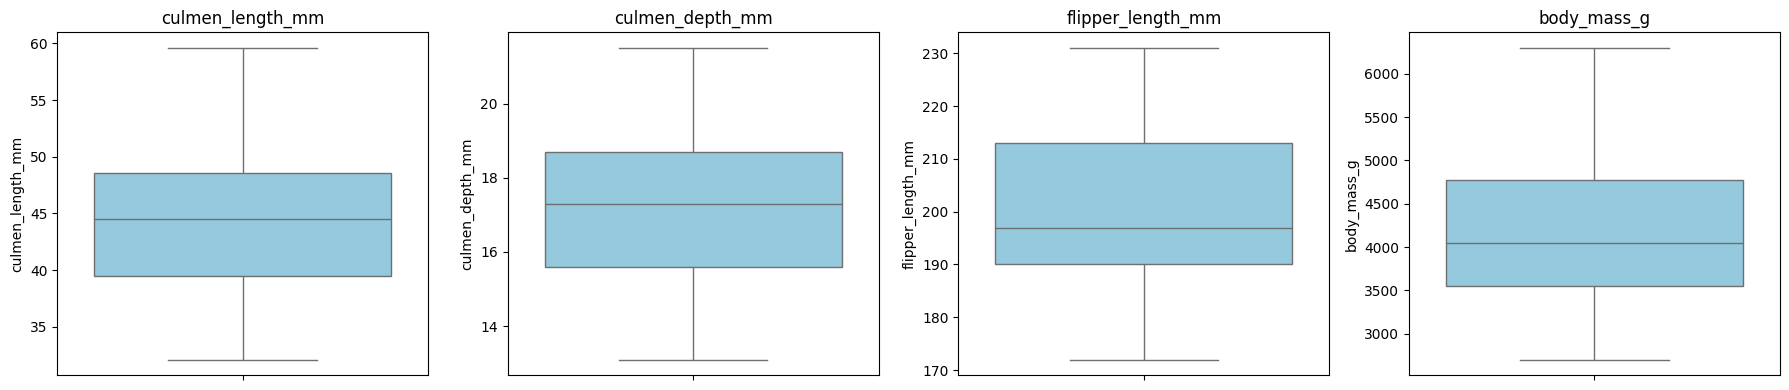

In [22]:
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

df_no_na_no_outlier_detection = df_no_na.copy()
eda_df = df_no_na.copy()

# Use boxplots and the IQR rule to decide which feature is the best LOF candidate.
fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 4))
for ax, feature in zip(axes, numeric_features):
    sns.boxplot(y=eda_df[feature], ax=ax, color="skyblue")
    ax.set_title(feature)
plt.tight_layout()
plt.show()

In [23]:
iqr_rows = []
for feature in numeric_features:
    q1 = eda_df[feature].quantile(0.25)
    q3 = eda_df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = (
        (eda_df[feature] < lower_bound) | (eda_df[feature] > upper_bound)
    ).sum()
    iqr_rows.append(
        {
            "feature": feature,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "iqr_outliers": int(outlier_count),
        }
    )

iqr_summary = pd.DataFrame(iqr_rows).sort_values("iqr_outliers", ascending=False)
display(iqr_summary)

,feature,q1,q3,iqr,iqr_outliers
0,culmen_length_mm,39.5,48.6,9.1,0
1,culmen_depth_mm,15.6,18.7,3.1,0
2,flipper_length_mm,190.0,213.0,23.0,0
3,body_mass_g,3550.0,4775.0,1225.0,0


No clear outliers were visible with the IQR rule, so 3 synthetic outliers were introduced in body_mass_g for LOF demonstration.


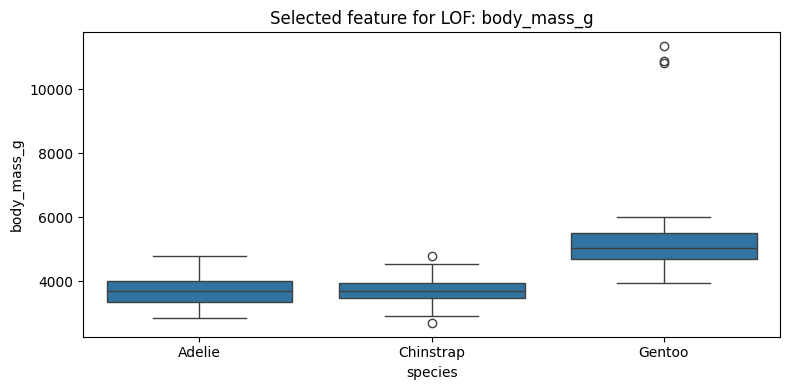

In [24]:
# select the feature with the most iqr outliers
selected_feature = iqr_summary.sort_values("iqr_outliers", ascending=False).iloc[0][
    "feature"
]
injected_outlier_indices = pd.Index([])
num_outliers_to_inject = 3
if iqr_summary.iloc[0]["iqr_outliers"] == 0:
    selected_feature = "body_mass_g"
    injected_outlier_indices = eda_df.nlargest(
        num_outliers_to_inject, selected_feature
    ).index
    eda_df.loc[injected_outlier_indices, selected_feature] = (
        eda_df.loc[injected_outlier_indices, selected_feature] * 1.8
    )
    print(
        f"No clear outliers were visible with the IQR rule, so {num_outliers_to_inject} synthetic outliers were introduced in {selected_feature} for LOF demonstration."
    )
else:
    print(
        f"{selected_feature} shows the strongest outlier signal in the EDA, so LOF will be applied to that feature."
    )

plt.figure(figsize=(8, 4))
sns.boxplot(x="species", y=selected_feature, data=eda_df)
plt.title(f"Selected feature for LOF: {selected_feature}")
plt.tight_layout()
plt.show()

LOF flagged 9 rows as outliers in body_mass_g.
Found 3 of the 3 synthetic outliers.


,species,sex,body_mass_g,lof_score
237,Gentoo,MALE,11340.0,25.385168
253,Gentoo,MALE,10890.0,23.628406
297,Gentoo,MALE,10800.0,23.277053
190,Chinstrap,FEMALE,2700.0,2.105934
337,Gentoo,MALE,6000.0,1.823625
331,Gentoo,MALE,5950.0,1.655838
299,Gentoo,MALE,5950.0,1.655838
58,Adelie,FEMALE,2850.0,1.570773
64,Adelie,FEMALE,2850.0,1.570773


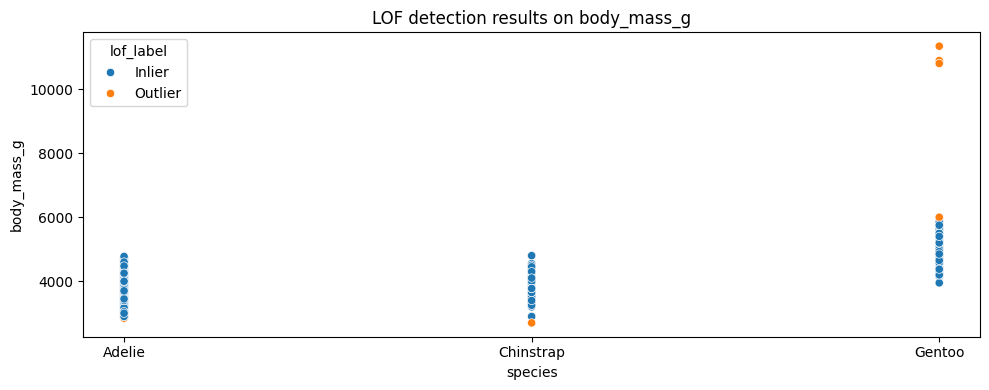

In [25]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
lof_labels = lof.fit_predict(eda_df[[selected_feature]])
lof_scores = -lof.negative_outlier_factor_

eda_df["lof_label"] = np.where(lof_labels == -1, "Outlier", "Inlier")
eda_df["lof_score"] = lof_scores

lof_results = eda_df.loc[
    eda_df["lof_label"] == "Outlier",
    ["species", "sex", selected_feature, "lof_score"],
].sort_values("lof_score", ascending=False)

print(f"LOF flagged {len(lof_results)} rows as outliers in {selected_feature}.")
if len(injected_outlier_indices) > 0:
    recovered_injected = (
        eda_df.loc[injected_outlier_indices, "lof_label"].eq("Outlier").sum()
    )
    print(f"Found {recovered_injected} of the 3 synthetic outliers.")

display(lof_results.head(10))

plt.figure(figsize=(10, 4))
plot_df = eda_df.reset_index()
sns.scatterplot(
    data=plot_df,
    x="species",
    y=selected_feature,
    hue="lof_label",
)
plt.title(f"LOF detection results on {selected_feature}")
plt.tight_layout()
plt.show()

We can see the 3 outliers we injected here as they are very far from all the other points in the graph.

In [26]:
# Drop the outliers
# Remove rows labeled as "Outlier" by LOF from the main dataframe
outlier_indices = eda_df.index[eda_df["lof_label"] == "Outlier"]
df_no_outliers = eda_df.drop(index=outlier_indices)

# drop the lof_label and lof_score columns
df_no_outliers = df_no_outliers.drop(columns=["lof_label", "lof_score"])

In [27]:
df_no_outliers.shape

(324, 9)

In [28]:
df_no_na_no_outlier_detection.shape

(333, 9)

## 2.4 DecisionTreeClassifier

In [29]:
from sklearn.tree import DecisionTreeClassifier

# choose baseline hyperparameters
criterion = "gini"
min_samples_split = 2
# start with a moderate max depth to avoid overfitting with super deep trees
max_depth = 5

dtc = DecisionTreeClassifier(
    criterion=criterion,
    min_samples_split=min_samples_split,
    max_depth=max_depth,
)

## 2.5 Feature Engineering

The 2 features we'll add are the ratios of culmen_length_mm / culmen_depth_mm and flipper_length_mm and body_mass_g

In [30]:
df_engineered = df_no_outliers.copy()
df_engineered["culmen_ratio"] = (
    df_engineered["culmen_length_mm"] / df_engineered["culmen_depth_mm"]
)
df_engineered["flipper_ratio"] = (
    df_engineered["flipper_length_mm"] / df_engineered["body_mass_g"]
)

df_no_na_no_outlier_detection_engineered = df_no_na_no_outlier_detection.copy()
df_no_na_no_outlier_detection_engineered["culmen_ratio"] = (
    df_no_na_no_outlier_detection_engineered["culmen_length_mm"]
    / df_no_na_no_outlier_detection_engineered["culmen_depth_mm"]
)
df_no_na_no_outlier_detection_engineered["flipper_ratio"] = (
    df_no_na_no_outlier_detection_engineered["flipper_length_mm"]
    / df_no_na_no_outlier_detection_engineered["body_mass_g"]
)

# convert sex to binary
df_no_na_no_outlier_detection_engineered["sex"] = (
    df_no_na_no_outlier_detection_engineered["sex"].map({"MALE": 1, "FEMALE": 0})
)
df_engineered["sex"] = df_engineered["sex"].map({"MALE": 1, "FEMALE": 0})
df_engineered.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen,culmen_ratio,flipper_ratio
0,Adelie,39.1,18.7,181.0,3750.0,1,False,False,True,2.090909,0.048267
1,Adelie,39.5,17.4,186.0,3800.0,0,False,False,True,2.270115,0.048947
2,Adelie,40.3,18.0,195.0,3250.0,0,False,False,True,2.238889,0.060000
4,Adelie,36.7,19.3,193.0,3450.0,0,False,False,True,1.901554,0.055942
5,Adelie,39.3,20.6,190.0,3650.0,1,False,False,True,1.907767,0.052055


## 2.6 Empirical Study

In [31]:
# Train/val/test split

X = df_engineered.drop(columns=["species"])
y = df_engineered["species"]

# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

# train val test split code inspired from https://datascience.stackexchange.com/questions/15135/train-test-validation-set-splitting-in-sklearn

# split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# split the remaining data into train (60%) and val (25%)
# since X_temp = 85% original, 20/85 ≈ 0.235 for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.235, random_state=42, stratify=y_temp
)

# To verify proportions:
print([len(X_train), len(X_val), len(X_test)])
print([len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)])

# do the same for the no_outlier_detection dataset
X_no_outlier_detection = df_no_na_no_outlier_detection_engineered.drop(
    columns=["species"]
)
y_no_outlier_detection = df_no_na_no_outlier_detection_engineered["species"]

(
    X_no_outlier_detection_temp,
    X_no_outlier_detection_test,
    y_no_outlier_detection_temp,
    y_no_outlier_detection_test,
) = train_test_split(
    X_no_outlier_detection,
    y_no_outlier_detection,
    test_size=0.15,
    random_state=42,
    stratify=y_no_outlier_detection,
)

(
    X_no_outlier_detection_train,
    X_no_outlier_detection_val,
    y_no_outlier_detection_train,
    y_no_outlier_detection_val,
) = train_test_split(
    X_no_outlier_detection_temp,
    y_no_outlier_detection_temp,
    test_size=0.235,
    random_state=42,
    stratify=y_no_outlier_detection_temp,
)

[210, 65, 49]
[0.6481481481481481, 0.2006172839506173, 0.15123456790123457]


We will use F1 score to evaluate the performance of the model, as it provides a balance between precision and recall.


In [32]:
# baseline model

baseline_model = DecisionTreeClassifier(
    criterion=criterion,
    min_samples_split=min_samples_split,
    max_depth=max_depth,
)

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate

validation_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
}

experiment_configs = {
    "baseline_all_features": {
        "drop_columns": [],
        "max_depth": max_depth,
        "description": "Use all data, including sex and the feature engineered ratios.",
        "x_val": X_val,
        "y_val": y_val,
    },
    "experiment_2_no_sex": {
        "drop_columns": ["sex"],
        "max_depth": max_depth,
        "description": "Remove sex to test whether it is a weak discriminant.",
        "x_val": X_val,
        "y_val": y_val,
    },
    "experiment_3_no_ratios": {
        "drop_columns": ["culmen_ratio", "flipper_ratio"],
        "max_depth": max_depth,
        "description": "Keep the original features but remove the aggregated ratio features.",
        "x_val": X_val,
        "y_val": y_val,
    },
    "experiment_4_no_max_depth": {
        "drop_columns": [],
        "max_depth": None,
        "description": "Keep all features but allow the tree to grow without a max-depth limit.",
        "x_val": X_val,
        "y_val": y_val,
    },
    "experiment_5_no_outlier_detection": {
        "drop_columns": [],
        "max_depth": max_depth,
        "description": "Keep all features and don't remove outliers.",
        "x_val": X_no_outlier_detection_val,
        "y_val": y_no_outlier_detection_val,
    },
}


def run_experiment(X_val, y_val, config, experiment_name):
    X_val_experiment = X_val.drop(columns=config["drop_columns"])

    print(f"Running experiment: {experiment_name}")
    model = DecisionTreeClassifier(
        criterion=criterion,
        min_samples_split=min_samples_split,
        max_depth=config["max_depth"],
        random_state=42,
    )

    cv_results = cross_validate(
        model,
        X_val_experiment,
        y_val,
        cv=validation_cv,
        scoring=scoring,
        return_estimator=True,
    )

    depths = [estimator.get_depth() for estimator in cv_results["estimator"]]
    leaves = [estimator.get_n_leaves() for estimator in cv_results["estimator"]]

    best_estimator = cv_results["estimator"][np.argmax(cv_results["test_f1_weighted"])]

    return {
        "experiment": experiment_name,
        "description": config["description"],
        "mean_accuracy": cv_results["test_accuracy"].mean(),
        "std_accuracy": cv_results["test_accuracy"].std(),
        "mean_f1_weighted": cv_results["test_f1_weighted"].mean(),
        "std_f1_weighted": cv_results["test_f1_weighted"].std(),
        "depths": depths,
        "leaves": leaves,
        "best_estimator": best_estimator,
    }


experiment_rows = []
for experiment_name, config in experiment_configs.items():
    res = run_experiment(config["x_val"], config["y_val"], config, experiment_name)
    experiment_rows.append(res)


experiment_results = pd.DataFrame(experiment_rows).sort_values(
    "mean_f1_weighted", ascending=False
)

metric_columns = [
    "mean_accuracy",
    "std_accuracy",
    "mean_f1_weighted",
    "std_f1_weighted",
]
experiment_results[metric_columns] = experiment_results[metric_columns].round(4)

display(experiment_results)

best_experiment = experiment_results.iloc[0]
print(
    f"Best validation-set configuration by weighted F1: {best_experiment['experiment']} "
    f"(accuracy={best_experiment['mean_accuracy']}, weighted F1={best_experiment['mean_f1_weighted']})."
)

Running experiment: baseline_all_features
Running experiment: experiment_2_no_sex
Running experiment: experiment_3_no_ratios
Running experiment: experiment_4_no_max_depth
Running experiment: experiment_5_no_outlier_detection


,experiment,description,mean_accuracy,std_accuracy,mean_f1_weighted,std_f1_weighted,depths,leaves,best_estimator
0,baseline_all_features,"Use all data, including sex and the feature en...",0.9853,0.0255,0.9849,0.0261,"[2, 2, 2, 2]","[3, 3, 3, 3]","DecisionTreeClassifier(max_depth=5, random_sta..."
3,experiment_4_no_max_depth,Keep all features but allow the tree to grow w...,0.9853,0.0255,0.9849,0.0261,"[2, 2, 2, 2]","[3, 3, 3, 3]",DecisionTreeClassifier(random_state=42)
1,experiment_2_no_sex,Remove sex to test whether it is a weak discri...,0.9844,0.0271,0.9848,0.0264,"[2, 2, 2, 2]","[3, 3, 3, 3]","DecisionTreeClassifier(max_depth=5, random_sta..."
2,experiment_3_no_ratios,Keep the original features but remove the aggr...,0.9550,0.0491,0.9555,0.0487,"[2, 2, 2, 2]","[3, 3, 3, 3]","DecisionTreeClassifier(max_depth=5, random_sta..."
4,experiment_5_no_outlier_detection,Keep all features and don't remove outliers.,0.9099,0.0314,0.9039,0.0370,"[2, 2, 2, 2]","[3, 3, 3, 3]","DecisionTreeClassifier(max_depth=5, random_sta..."


Best validation-set configuration by weighted F1: baseline_all_features (accuracy=0.9853, weighted F1=0.9849).


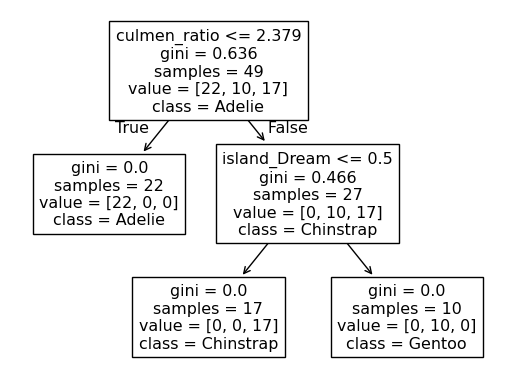

In [34]:
from sklearn.tree import plot_tree

best_cv_model = best_experiment.best_estimator
plot_tree(
    best_cv_model,
    feature_names=X_val.columns,
    class_names=y_val.unique(),
)
plt.show()

In [35]:
# retrain best model on train + val and evaluate on test set
from sklearn.metrics import f1_score, accuracy_score

best_model = best_experiment.best_estimator
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average="weighted")
accuracy = accuracy_score(y_test, y_pred)
print(f"Test weighted F1: {f1:.4f}, Test accuracy: {accuracy:.4f}")

Test weighted F1: 0.9384, Test accuracy: 0.9388


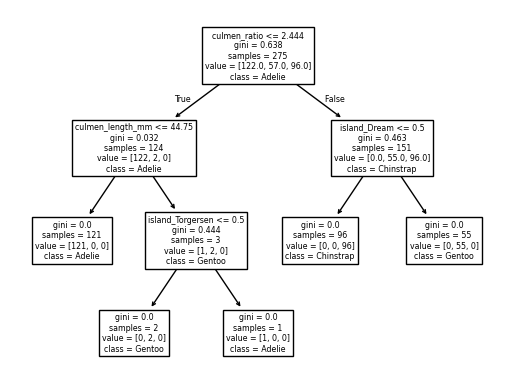

In [36]:
plot_tree(
    best_model,
    feature_names=X_val.columns,
    class_names=y_val.unique(),
)
plt.show()

## 2.7 Result Analysis

Looking at the results of our 5 experiments, we see the following:
- The max_depth experiment didn't change anything, because all of the trees built had a max depth of 2 anyways
- The feature engineered ratios provide a strong discriminating power, as all experiments that used those features (baseline, experiment 2, experiment 4) scored better and with less variance than experiment 3, which did not use them
    - We can also see this from the plots above, showing the cv best decision tree and final trained decision tree respectively, that culmen_ratio is the best predictor as it is at the top of the tree, meaning it provides the best reduction in Gini index across the dataset (best at being a useful discriminant)
- Sex is not a strong discriminant as it didn't show much meaningful difference in results compared to baseline. This makes sense as biologically, we'd expect the ratio to be roughly 50/50 no matter the species, so it wouldn't be useful in a decision tree or any classifier.
- Performance greatly suffered when outliers were not removed (experiment 5), showing it's important to deal with them properly for classification.

**Unseen test set vs cross-validation results**
- The results on the unseen test set were worse than those on the cross-validated set, but that is to be expected. In the cross-validation phase, we train on 75% of a 20% split (so we train on 15% of the total data and validate on 5%), meaning it is likely that our model may be missing examples that do occur in the test set or in the real world. Also, since our "test" proportion during cross-validation is small, there may be less "noisy" or "difficult" points that may be affecting our results on the final test set.

# References

- StackExchange (2016). Train/Test/Validation Set Splitting in Sklearn. https://datascience.stackexchange.com/questions/15135/train-test-validation-set-splitting-in-sklearn